# Binary Network Intrusion Detection (CIC-IDS2017)

This notebook trains and compares two **Benign vs Attack** models: a Random Forest and an MLP neural network. Every non-BENIGN CIC-IDS2017 label becomes `Attack`. The split is stratified, so both categories occur in the training and independent test data.

Run the cells from top to bottom using the `Python 3.12 (Realtime IDS)` kernel.

In [1]:
from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / 'data' / 'cicids2017'
MODEL_DIR = PROJECT_ROOT / 'models'
MAX_PER_CLASS = 70_000
RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

print('Project:', PROJECT_ROOT)
print('Dataset:', DATA_DIR)

Project: c:\Project\Realtime-IDS-GitHub
Dataset: c:\Project\Realtime-IDS-GitHub\data\cicids2017


In [2]:
def canonical_name(name):
    name = name.strip().lower().replace('forward', 'fwd').replace('backward', 'bwd').replace('packets', 'packet')
    return re.sub(r'[^a-z0-9]+', '_', name).strip('_')

EXCLUDED = {'flow_id', 'src_ip', 'dst_ip', 'source_ip', 'destination_ip',
            'src_port', 'dst_port', 'source_port', 'destination_port', 'timestamp', 'label'}

def usable_columns(columns):
    return [c for c in columns if canonical_name(c) not in EXCLUDED and not canonical_name(c).endswith('_1')]

def read_balanced_binary_sample():
    files = sorted(DATA_DIR.rglob('*.csv'))
    if not files:
        raise FileNotFoundError(f'No CSV files found below {DATA_DIR}')
    rng, pieces, selected = np.random.default_rng(RANDOM_STATE), [], {0: 0, 1: 0}
    columns = None
    per_file_limit = MAX_PER_CLASS // len(files)
    for path in files:
        print('Reading', path.name)
        from_file = {0: 0, 1: 0}
        for chunk in pd.read_csv(path, chunksize=50_000, low_memory=False):
            chunk.columns = [c.strip() for c in chunk.columns]
            label_col = next((c for c in chunk.columns if canonical_name(c) == 'label'), None)
            if label_col is None: raise ValueError(f'No Label column in {path.name}')
            if columns is None: columns = usable_columns(chunk.columns.tolist())
            target = (chunk[label_col].astype(str).str.strip().str.upper() != 'BENIGN').astype('int8')
            for value in (0, 1):
                remaining = min(MAX_PER_CLASS-selected[value], per_file_limit-from_file[value])
                candidates = chunk.loc[target.eq(value), columns].copy()
                if remaining <= 0 or candidates.empty: continue
                if len(candidates) > remaining:
                    candidates = candidates.loc[rng.choice(candidates.index, remaining, replace=False)]
                candidates['target'] = value
                pieces.append(candidates); selected[value] += len(candidates); from_file[value] += len(candidates)
            if all(from_file[v] >= per_file_limit for v in (0, 1)): break
    data = pd.concat(pieces, ignore_index=True)
    size = data['target'].value_counts().min()
    data = data.groupby('target', group_keys=False).sample(n=size, random_state=RANDOM_STATE).sample(frac=1, random_state=RANDOM_STATE)
    y = data.pop('target').reset_index(drop=True)
    x = data.reset_index(drop=True); x.columns = [canonical_name(c) for c in x.columns]
    x = x.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan)
    return x, y

X, y = read_balanced_binary_sample()
print(f'Features: {X.shape[1]} | Benign: {(y == 0).sum():,} | Attack: {(y == 1).sum():,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Training flows: {len(y_train):,}; test flows: {len(y_test):,}')

Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading Monday-WorkingHours.pcap_ISCX.csv
Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading Tuesday-WorkingHours.pcap_ISCX.csv
Reading Wednesday-workingHours.pcap_ISCX.csv
Features: 76 | Benign: 39,182 | Attack: 39,182
Training flows: 62,691; test flows: 15,673


## 1. Random Forest

The Random Forest uses median imputation and can work directly with unscaled numeric features.

Random Forest independent test accuracy: 99.55%
              precision    recall  f1-score   support

      Benign     0.9933    0.9977    0.9955      7837
      Attack     0.9977    0.9932    0.9955      7836

    accuracy                         0.9955     15673
   macro avg     0.9955    0.9955    0.9955     15673
weighted avg     0.9955    0.9955    0.9955     15673



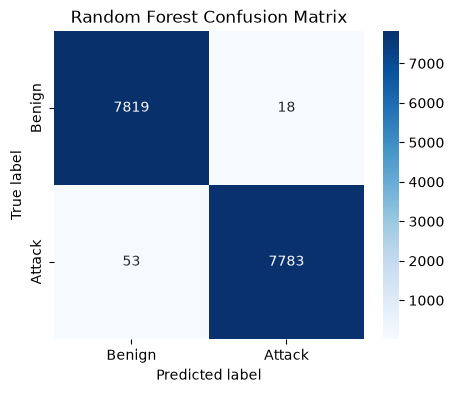

Saved Random Forest: c:\Project\Realtime-IDS-GitHub\models\cicids2017_random_forest.joblib


In [3]:
rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(
        n_estimators=150, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
    )),
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print(f'Random Forest independent test accuracy: {accuracy_score(y_test, rf_pred):.2%}')
print(classification_report(y_test, rf_pred, target_names=['Benign', 'Attack'], digits=4))
rf_matrix = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(rf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.xlabel('Predicted label'); plt.ylabel('True label'); plt.title('Random Forest Confusion Matrix'); plt.show()

MODEL_DIR.mkdir(exist_ok=True)
rf_path = MODEL_DIR / 'cicids2017_random_forest.joblib'
joblib.dump({'model': rf_model, 'feature_names': X.columns.tolist()}, rf_path)
print('Saved Random Forest:', rf_path)

## 2. MLP neural-network comparison

The MLP requires standardised features. The imputer and scaler are fit on the training flows only, preventing test-set leakage. Early stopping ends training when validation loss no longer improves.

In [4]:
mlp_imputer, scaler = SimpleImputer(strategy='median'), StandardScaler()
X_train_mlp = scaler.fit_transform(mlp_imputer.fit_transform(X_train)).astype('float32')
X_test_mlp = scaler.transform(mlp_imputer.transform(X_test)).astype('float32')

mlp_model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_mlp.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.20),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-5),
]
history = mlp_model.fit(
    X_train_mlp, y_train, validation_split=0.15, epochs=40, batch_size=512, callbacks=callbacks, verbose=2
)

mlp_prob = mlp_model.predict(X_test_mlp, verbose=0).ravel()
mlp_pred = (mlp_prob >= 0.50).astype(int)
print(f'MLP independent test accuracy: {accuracy_score(y_test, mlp_pred):.2%}')
print(classification_report(y_test, mlp_pred, target_names=['Benign', 'Attack'], digits=4))

Epoch 1/40
105/105 - 1s - 9ms/step - accuracy: 0.8210 - loss: 0.3754 - val_accuracy: 0.8461 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 2/40
105/105 - 0s - 2ms/step - accuracy: 0.9042 - loss: 0.2308 - val_accuracy: 0.9219 - val_loss: 0.2117 - learning_rate: 0.0010
Epoch 3/40
105/105 - 0s - 3ms/step - accuracy: 0.9210 - loss: 0.1957 - val_accuracy: 0.9410 - val_loss: 0.1773 - learning_rate: 0.0010
Epoch 4/40
105/105 - 0s - 2ms/step - accuracy: 0.9311 - loss: 0.1715 - val_accuracy: 0.9468 - val_loss: 0.1589 - learning_rate: 0.0010
Epoch 5/40
105/105 - 0s - 3ms/step - accuracy: 0.9398 - loss: 0.1535 - val_accuracy: 0.9484 - val_loss: 0.1461 - learning_rate: 0.0010
Epoch 6/40
105/105 - 0s - 2ms/step - accuracy: 0.9459 - loss: 0.1382 - val_accuracy: 0.9510 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 7/40
105/105 - 0s - 2ms/step - accuracy: 0.9488 - loss: 0.1287 - val_accuracy: 0.9528 - val_loss: 0.1119 - learning_rate: 0.0010
Epoch 8/40
105/105 - 0s - 2ms/step - accuracy: 0.9522 -

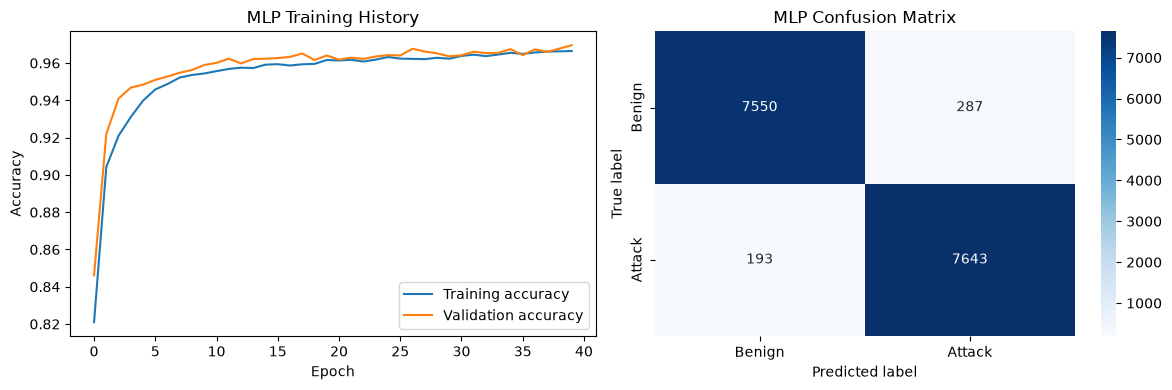

Saved MLP: c:\Project\Realtime-IDS-GitHub\models\cicids2017_binary_mlp.keras
Saved MLP preprocessing: c:\Project\Realtime-IDS-GitHub\models\cicids2017_binary_mlp_preprocessing.joblib


In [5]:
mlp_matrix = confusion_matrix(y_test, mlp_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Training accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[0].set(xlabel='Epoch', ylabel='Accuracy', title='MLP Training History')
axes[0].legend()
sns.heatmap(mlp_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'], ax=axes[1])
axes[1].set(xlabel='Predicted label', ylabel='True label', title='MLP Confusion Matrix')
plt.tight_layout(); plt.show()

mlp_path = MODEL_DIR / 'cicids2017_binary_mlp.keras'
preprocess_path = MODEL_DIR / 'cicids2017_binary_mlp_preprocessing.joblib'
mlp_model.save(mlp_path)
joblib.dump({'imputer': mlp_imputer, 'scaler': scaler, 'feature_columns': X.columns.tolist(), 'classes': ['Benign', 'Attack'], 'model_type': 'binary_mlp'}, preprocess_path)
print('Saved MLP:', mlp_path)
print('Saved MLP preprocessing:', preprocess_path)